In [1]:
import os
import cv2
import numpy as np
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


def load_dataset(dataset_path, img_size=(90, 90)):
    X, y = [], []

    for person_name in sorted(os.listdir(dataset_path)):
        person_dir = os.path.join(dataset_path, person_name)
        if not os.path.isdir(person_dir):
            continue

        for file in os.listdir(person_dir):
            img_path = os.path.join(person_dir, file)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            img = cv2.resize(img, img_size)
            img = img.astype(np.float32) / 255.0

            X.append(img.flatten())
            y.append(person_name)

    return np.array(X), np.array(y)


def sklearn_pca_lda_knn(train_path, test_path, img_size=(90, 90), n_pca=40, n_neighbors=1):
    X_train, y_train = load_dataset(train_path, img_size)
    X_test, y_test = load_dataset(test_path, img_size)

    print("X_train:", X_train.shape)
    print("X_test :", X_test.shape)

    # PCA
    pca = PCA(n_components=n_pca, whiten=True, svd_solver="randomized", random_state=42)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    # LDA
    n_classes = len(np.unique(y_train))
    lda_dim = min(n_classes - 1, X_train_pca.shape[1])
    lda = LinearDiscriminantAnalysis(n_components=lda_dim)
    X_train_lda = lda.fit_transform(X_train_pca, y_train)
    X_test_lda = lda.transform(X_test_pca)

    # KNN
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(X_train_lda, y_train)
    y_pred = clf.predict(X_test_lda)

    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)

    return {
        "pca": pca,
        "lda": lda,
        "clf": clf,
        "accuracy": acc,
        "y_pred": y_pred,
        "y_test": y_test
    }

In [7]:
results_1nn = sklearn_pca_lda_knn(
    train_path="./datasets/datasets_2/train",
    test_path="./datasets/datasets_2/test",
    img_size=(90, 90),
    n_pca=10,
    n_neighbors=1
)

X_train: (77, 8100)
X_test : (22, 8100)
Accuracy: 0.5909090909090909


In [10]:
results_5nn = sklearn_pca_lda_knn(
    train_path="./datasets/datasets_2/train",
    test_path="./datasets/datasets_2/test",
    img_size=(90, 90),
    n_pca=50,
    n_neighbors=5
)

X_train: (77, 8100)
X_test : (22, 8100)
Accuracy: 0.6818181818181818


X_train: (77, 8100)
X_test : (22, 8100)
Accuracy: 0.5909090909090909
X_train: (77, 8100)
X_test : (22, 8100)
Accuracy: 0.6363636363636364
X_train: (77, 8100)
X_test : (22, 8100)
Accuracy: 0.5909090909090909
X_train: (77, 8100)
X_test : (22, 8100)
Accuracy: 0.6363636363636364
X_train: (77, 8100)
X_test : (22, 8100)
Accuracy: 0.5
X_train: (77, 8100)
X_test : (22, 8100)
Accuracy: 0.5
X_train: (77, 8100)
X_test : (22, 8100)
Accuracy: 0.5
X_train: (77, 8100)
X_test : (22, 8100)
Accuracy: 0.5
X_train: (77, 8100)
X_test : (22, 8100)
Accuracy: 0.45454545454545453
X_train: (77, 8100)
X_test : (22, 8100)
Accuracy: 0.5


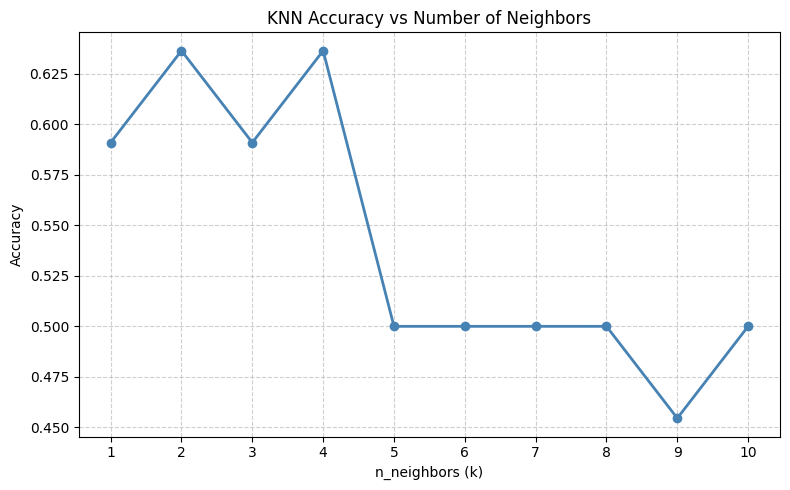

k= 1 → Accuracy: 0.5909
k= 2 → Accuracy: 0.6364
k= 3 → Accuracy: 0.5909
k= 4 → Accuracy: 0.6364
k= 5 → Accuracy: 0.5000
k= 6 → Accuracy: 0.5000
k= 7 → Accuracy: 0.5000
k= 8 → Accuracy: 0.5000
k= 9 → Accuracy: 0.4545
k=10 → Accuracy: 0.5000


In [12]:
import matplotlib.pyplot as plt

neighbor_values = range(1, 11)  # test k=1 to k=10
accuracies = []

for k in neighbor_values:
    results = sklearn_pca_lda_knn(
        train_path="./datasets/datasets_2/train",
        test_path="./datasets/datasets_2/test",
        img_size=(90, 90),
        n_pca=10,
        n_neighbors=k
    )
    accuracies.append(results["accuracy"])  # adjust key if different

# Plot
plt.figure(figsize=(8, 5))
plt.plot(neighbor_values, accuracies, marker='o', linewidth=2, markersize=6, color='steelblue')
plt.title("KNN Accuracy vs Number of Neighbors")
plt.xlabel("n_neighbors (k)")
plt.ylabel("Accuracy")
plt.xticks(neighbor_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Print summary
for k, acc in zip(neighbor_values, accuracies):
    print(f"k={k:2d} → Accuracy: {acc:.4f}")

X_train: (77, 8100)
X_test : (22, 8100)
Accuracy: 0.5909090909090909
X_train: (77, 8100)
X_test : (22, 8100)
Accuracy: 0.6363636363636364
X_train: (77, 8100)
X_test : (22, 8100)
Accuracy: 0.5909090909090909
X_train: (77, 8100)
X_test : (22, 8100)
Accuracy: 0.6363636363636364
X_train: (77, 8100)
X_test : (22, 8100)
Accuracy: 0.5
X_train: (77, 8100)
X_test : (22, 8100)
Accuracy: 0.5
X_train: (77, 8100)
X_test : (22, 8100)
Accuracy: 0.5
X_train: (77, 8100)
X_test : (22, 8100)
Accuracy: 0.5
X_train: (77, 8100)
X_test : (22, 8100)
Accuracy: 0.45454545454545453
X_train: (77, 8100)
X_test : (22, 8100)
Accuracy: 0.5
X_train: (77, 8100)
X_test : (22, 8100)
Accuracy: 0.5909090909090909
X_train: (77, 8100)
X_test : (22, 8100)
Accuracy: 0.5909090909090909
X_train: (77, 8100)
X_test : (22, 8100)
Accuracy: 0.6363636363636364
X_train: (77, 8100)
X_test : (22, 8100)
Accuracy: 0.6818181818181818
X_train: (77, 8100)
X_test : (22, 8100)
Accuracy: 0.6363636363636364
X_train: (77, 8100)
X_test : (22, 8100)

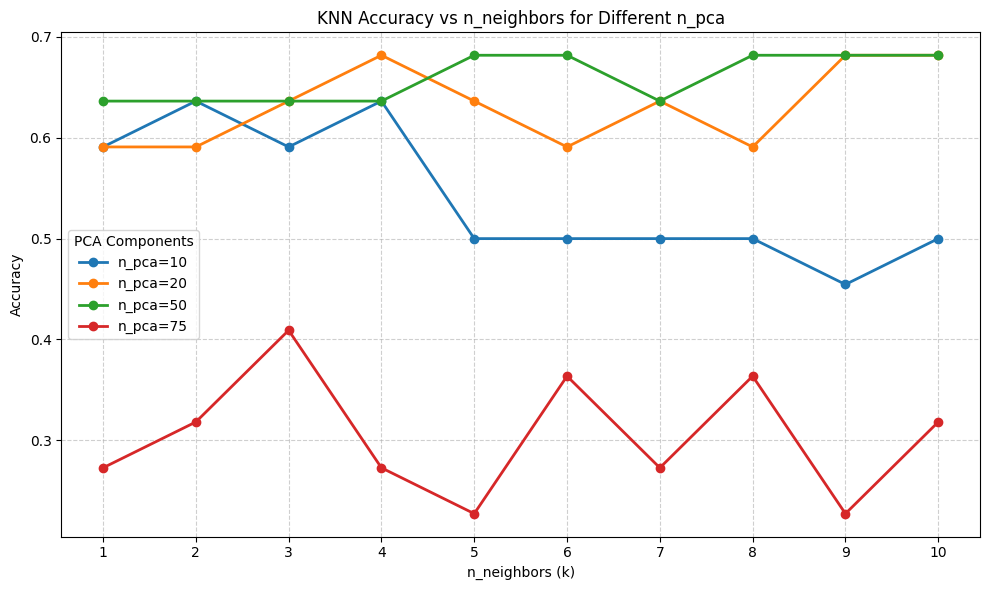

k    n_pca=10       n_pca=20       n_pca=50       n_pca=75       
-----------------------------------------------------------------
1    0.2727         0.2727         0.2727         0.2727         
2    0.3182         0.3182         0.3182         0.3182         
3    0.4091         0.4091         0.4091         0.4091         
4    0.2727         0.2727         0.2727         0.2727         
5    0.2273         0.2273         0.2273         0.2273         
6    0.3636         0.3636         0.3636         0.3636         
7    0.2727         0.2727         0.2727         0.2727         
8    0.3636         0.3636         0.3636         0.3636         
9    0.2273         0.2273         0.2273         0.2273         
10   0.3182         0.3182         0.3182         0.3182         


In [15]:
import matplotlib.pyplot as plt
import numpy as np

neighbor_values = range(1, 11)   # k=1 to k=10
pca_values      = [10, 20, 50, 75]  # PCA components to compare

plt.figure(figsize=(10, 6))

for n_pca in pca_values:
    accuracies = []
    for k in neighbor_values:
        results = sklearn_pca_lda_knn(
            train_path="./datasets/datasets_2/train",
            test_path="./datasets/datasets_2/test",
            img_size=(90, 90),
            n_pca=n_pca,
            n_neighbors=k
        )
        accuracies.append(results["accuracy"])  # adjust key if needed
    plt.plot(neighbor_values, accuracies, marker='o', linewidth=2, markersize=6, label=f"n_pca={n_pca}")

plt.title("KNN Accuracy vs n_neighbors for Different n_pca")
plt.xlabel("n_neighbors (k)")
plt.ylabel("Accuracy")
plt.xticks(neighbor_values)
plt.legend(title="PCA Components")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Print summary table
print(f"{'k':<5}", end="")
for n_pca in pca_values:
    print(f"{'n_pca='+str(n_pca):<15}", end="")
print()
print("-" * (5 + 15 * len(pca_values)))
for i, k in enumerate(neighbor_values):
    print(f"{k:<5}", end="")
    for j, n_pca in enumerate(pca_values):
        # re-fetch from stored results if you cached them, or recompute
        print(f"{accuracies[i]:<15.4f}", end="")  # note: store per pca if needed
    print()

In [3]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


def sklearn_pca_svm(train_path, test_path, img_size=(90, 90), n_pca=50):
    X_train, y_train = load_dataset(train_path, img_size)
    X_test, y_test = load_dataset(test_path, img_size)

    pca = PCA(n_components=n_pca, whiten=True, svd_solver="randomized", random_state=42)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    clf = SVC(kernel="linear", C=1.0)
    clf.fit(X_train_pca, y_train)
    y_pred = clf.predict(X_test_pca)

    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)

    return {
        "pca": pca,
        "clf": clf,
        "accuracy": acc,
        "y_pred": y_pred,
        "y_test": y_test
    }

In [4]:
results_svm = sklearn_pca_svm(
    train_path="./datasets/datasets_2/train",
    test_path="./datasets/datasets_2/test",
    img_size=(90, 90),
    n_pca=44
)

Accuracy: 0.7727272727272727


In [ ]:
import joblib

pca=results_5nn["pca"]
lda=results_5nn["lda"] if "lda" in results_5nn else None
clf=results_5nn["clf"]

# Save fitted models
joblib.dump(pca, "pca_model.pkl")
joblib.dump(lda, "lda_model.pkl")
joblib.dump(clf, "clf_model.pkl")
print("Models saved.")


Models saved.


In [41]:
import cv2
import numpy as np
import joblib
from collections import deque

# ── CONFIG ──────────────────────────────────────────────
IMG_SIZE       = (90, 90)
CONFIDENCE_THR = 0.5
SMOOTH_WINDOW  = 10
# ────────────────────────────────────────────────────────

# Detectors
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
eye_cascade  = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

buffers = {}

# ── Preprocessing (mirrors your script exactly) ──────────
def normalize_lighting(gray):
    clahe      = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clahe_img  = clahe.apply(gray)
    normalized = cv2.normalize(clahe_img, None, 0, 255, cv2.NORM_MINMAX)
    return normalized

def align_face(gray, x, y, w, h):
    """Same align_face() from your preprocessing script."""
    face_roi = gray[y : y + h//2, x : x + w]
    eyes = eye_cascade.detectMultiScale(
        face_roi, scaleFactor=1.1, minNeighbors=8,
        minSize=(20, 20), maxSize=(w//3, h//3)
    )
    if len(eyes) < 2:
        return gray, x, y, w, h

    eyes = sorted(eyes, key=lambda e: e[2] * e[3], reverse=True)[:2]
    eyes = sorted(eyes, key=lambda e: e[0])

    (ex1, ey1, ew1, eh1) = eyes[0]
    (ex2, ey2, ew2, eh2) = eyes[1]

    left_eye_center  = (int(x + ex1 + ew1 // 2), int(y + ey1 + eh1 // 2))
    right_eye_center = (int(x + ex2 + ew2 // 2), int(y + ey2 + eh2 // 2))

    if abs(left_eye_center[1] - right_eye_center[1]) > h * 0.15:
        return gray, x, y, w, h
    if abs(left_eye_center[0] - right_eye_center[0]) < w * 0.2:
        return gray, x, y, w, h

    dx    = right_eye_center[0] - left_eye_center[0]
    dy    = right_eye_center[1] - left_eye_center[1]
    angle = np.degrees(np.arctan2(dy, dx))

    if abs(angle) > 30:
        return gray, x, y, w, h

    eye_mid = (
        int((left_eye_center[0] + right_eye_center[0]) // 2),
        int((left_eye_center[1] + right_eye_center[1]) // 2)
    )
    M       = cv2.getRotationMatrix2D(eye_mid, angle, 1.0)
    aligned = cv2.warpAffine(gray, M, (gray.shape[1], gray.shape[0]),
                              flags=cv2.INTER_CUBIC,
                              borderMode=cv2.BORDER_REPLICATE)
    return aligned, x, y, w, h

def preprocess_face(gray_crop, h_orig, w_orig, x, y, w, h):
    """Mirrors steps 4-6 of your preprocessing script."""
    # Step 4: Olivetti-style crop margins
    forehead_extra = int(h * 0.15)
    chin_extra     = int(h * 0.05)

    x1 = max(0, x)
    y1 = max(0, y - forehead_extra)
    x2 = min(w_orig, x + w)
    y2 = min(h_orig, y + h + chin_extra)

    crop = gray_crop[y1:y2, x1:x2]
    if crop.size == 0:
        return None

    # Step 5: Resize
    face = cv2.resize(crop, IMG_SIZE, interpolation=cv2.INTER_AREA)
    # Step 6: CLAHE + normalize
    face = normalize_lighting(face)
    # load_dataset: float32 + flatten
    face = face.astype(np.float32) / 255.0
    return face.flatten().reshape(1, -1)

def predict_face(face_vec):
    pca_vec    = pca.transform(face_vec)
    lda_vec    = lda.transform(pca_vec)
    proba      = clf.predict_proba(lda_vec)[0]
    confidence = proba.max()
    label      = clf.classes_[proba.argmax()]
    return label, confidence

def smooth_prediction(face_id, label):
    if face_id not in buffers:
        buffers[face_id] = deque(maxlen=SMOOTH_WINDOW)
    buffers[face_id].append(label)
    return max(set(buffers[face_id]), key=buffers[face_id].count)

# ── Main Loop ─────────────────────────────────────────────
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    h_img, w_img = frame.shape[:2]
    gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect faces (mirrors your multi-scale loop)
    faces = []
    for scale in [1.05, 1.1, 1.15, 1.2]:
        detected = face_cascade.detectMultiScale(
            gray, scaleFactor=scale, minNeighbors=4, minSize=(40, 40)
        )
        if len(detected) > 0:
            faces = detected
            break

    # Take largest face only (mirrors your script)
    if len(faces) > 0:
        faces = sorted(faces, key=lambda r: r[2] * r[3], reverse=True)

    for i, (x, y, w, h) in enumerate(faces):
        aligned_gray, x, y, w, h = align_face(gray, x, y, w, h)
        vec = preprocess_face(aligned_gray, h_img, w_img, x, y, w, h)

        if vec is None:
            continue

        label, confidence = predict_face(vec)

        if confidence < CONFIDENCE_THR:
            label = "Unknown"

        label = smooth_prediction(face_id=i, label=label)

        color = (0, 255, 0) if label != "Unknown" else (0, 0, 255)
        cv2.rectangle(frame, (x, y), (x+w, y+h), color, 2)
        cv2.putText(frame, f"{label} ({confidence:.2f})",
                    (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    cv2.imshow("Face Classification", frame)
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()

[ WARN:0@1865.384] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[video4linux2,v4l2 @ 0x274fc8c0] ioctl(VIDIOC_G_INPUT): Inappropriate ioctl for device
[ERROR:0@1865.385] global obsensor_uvc_stream_channel.cpp:163 getStreamChannelGroup Camera index out of range


In [44]:
from IPython.display import display, Javascript
from ipywidgets import widgets
import base64, cv2, numpy as np, joblib
from collections import deque



face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
eye_cascade  = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

IMG_SIZE       = (90, 90)
CONFIDENCE_THR = 0.5
buffers        = {}

# ── Paste your normalize_lighting + align_face + preprocess_face here ──
def normalize_lighting(gray):
    clahe      = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clahe_img  = clahe.apply(gray)
    normalized = cv2.normalize(clahe_img, None, 0, 255, cv2.NORM_MINMAX)
    return normalized

def preprocess_face(gray_crop, h_img, w_img, x, y, w, h):
    forehead_extra = int(h * 0.15)
    chin_extra     = int(h * 0.05)
    x1 = max(0, x);          y1 = max(0, y - forehead_extra)
    x2 = min(w_img, x + w);  y2 = min(h_img, y + h + chin_extra)
    crop = gray_crop[y1:y2, x1:x2]
    if crop.size == 0:
        return None
    face = cv2.resize(crop, IMG_SIZE, interpolation=cv2.INTER_AREA)
    face = normalize_lighting(face)
    face = face.astype(np.float32) / 255.0
    return face.flatten().reshape(1, -1)

def smooth_prediction(face_id, label):
    if face_id not in buffers:
        buffers[face_id] = deque(maxlen=10)
    buffers[face_id].append(label)
    return max(set(buffers[face_id]), key=buffers[face_id].count)

def process_frame(img_b64):
    """Decode base64 frame → detect → classify → return annotated base64."""
    img_data = base64.b64decode(img_b64.split(",")[1])
    nparr    = np.frombuffer(img_data, np.uint8)
    frame    = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
    if frame is None:
        return img_b64

    h_img, w_img = frame.shape[:2]
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = []
    for scale in [1.05, 1.1, 1.15, 1.2]:
        detected = face_cascade.detectMultiScale(
            gray, scaleFactor=scale, minNeighbors=4, minSize=(40, 40)
        )
        if len(detected) > 0:
            faces = sorted(detected, key=lambda r: r[2]*r[3], reverse=True)
            break

    for i, (x, y, w, h) in enumerate(faces):
        vec = preprocess_face(gray, h_img, w_img, x, y, w, h)
        if vec is None:
            continue

        pca_vec    = pca.transform(vec)
        lda_vec    = lda.transform(pca_vec)
        proba      = clf.predict_proba(lda_vec)[0]
        confidence = proba.max()
        label      = clf.classes_[proba.argmax()]

        if confidence < CONFIDENCE_THR:
            label = "Unknown"
        label = smooth_prediction(i, label)

        color = (0, 255, 0) if label != "Unknown" else (0, 0, 255)
        cv2.rectangle(frame, (x, y), (x+w, y+h), color, 2)
        cv2.putText(frame, f"{label} ({confidence:.2f})",
                    (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    _, buffer = cv2.imencode(".jpg", frame)
    b64_out = base64.b64encode(buffer).decode("utf-8")
    return f"data:image/jpeg;base64,{b64_out}"

print("✅ Backend ready.")

✅ Backend ready.


In [ ]:
import cv2
import numpy as np
import joblib
import ipywidgets as widgets
from IPython.display import display
from collections import deque

# ── CONFIG ───────────────────────────────────────────────
IMG_SIZE       = (90, 90)
CONFIDENCE_THR = 0.5
SMOOTH_WINDOW  = 10
# ─────────────────────────────────────────────────────────


face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
eye_cascade  = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_eye.xml")

buffers = {}

def normalize_lighting(gray):
    clahe      = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clahe_img  = clahe.apply(gray)
    normalized = cv2.normalize(clahe_img, None, 0, 255, cv2.NORM_MINMAX)
    return normalized

def align_face(gray, x, y, w, h):
    face_roi = gray[y : y + h//2, x : x + w]
    eyes = eye_cascade.detectMultiScale(
        face_roi, scaleFactor=1.1, minNeighbors=8,
        minSize=(20, 20), maxSize=(w//3, h//3)
    )
    if len(eyes) < 2:
        return gray, x, y, w, h
    eyes = sorted(eyes, key=lambda e: e[2]*e[3], reverse=True)[:2]
    eyes = sorted(eyes, key=lambda e: e[0])
    (ex1,ey1,ew1,eh1) = eyes[0]
    (ex2,ey2,ew2,eh2) = eyes[1]
    left_eye_center  = (int(x+ex1+ew1//2), int(y+ey1+eh1//2))
    right_eye_center = (int(x+ex2+ew2//2), int(y+ey2+eh2//2))
    if abs(left_eye_center[1]-right_eye_center[1]) > h*0.15:
        return gray, x, y, w, h
    if abs(left_eye_center[0]-right_eye_center[0]) < w*0.2:
        return gray, x, y, w, h
    dx    = right_eye_center[0] - left_eye_center[0]
    dy    = right_eye_center[1] - left_eye_center[1]
    angle = np.degrees(np.arctan2(dy, dx))
    if abs(angle) > 30:
        return gray, x, y, w, h
    eye_mid = (int((left_eye_center[0]+right_eye_center[0])//2),
               int((left_eye_center[1]+right_eye_center[1])//2))
    M       = cv2.getRotationMatrix2D(eye_mid, angle, 1.0)
    aligned = cv2.warpAffine(gray, M, (gray.shape[1], gray.shape[0]),
                              flags=cv2.INTER_CUBIC,
                              borderMode=cv2.BORDER_REPLICATE)
    return aligned, x, y, w, h

def preprocess_face(gray_crop, h_img, w_img, x, y, w, h):
    forehead_extra = int(h * 0.15)
    chin_extra     = int(h * 0.05)
    x1 = max(0, x);          y1 = max(0, y - forehead_extra)
    x2 = min(w_img, x + w);  y2 = min(h_img, y + h + chin_extra)
    crop = gray_crop[y1:y2, x1:x2]
    if crop.size == 0:
        return None
    face = cv2.resize(crop, IMG_SIZE, interpolation=cv2.INTER_AREA)
    face = normalize_lighting(face)
    face = face.astype(np.float32) / 255.0
    return face.flatten().reshape(1, -1)

def smooth_prediction(face_id, label):
    if face_id not in buffers:
        buffers[face_id] = deque(maxlen=SMOOTH_WINDOW)
    buffers[face_id].append(label)
    return max(set(buffers[face_id]), key=buffers[face_id].count)

def frame_to_jpeg(frame):
    _, buf = cv2.imencode(".jpg", frame)
    return bytes(buf)

# ── Widgets ──────────────────────────────────────────────
img_widget = widgets.Image(format="jpeg", width=640, height=480)
lbl_widget = widgets.Label(value="Starting...")
btn_stop   = widgets.Button(description="■ Stop", button_style="danger")
running    = [True]

def on_stop(b):
    running[0] = False

btn_stop.on_click(on_stop)
display(widgets.VBox([widgets.HBox([btn_stop]), lbl_widget, img_widget]))

# ── Capture Loop ─────────────────────────────────────────
cap = cv2.VideoCapture(0)

while running[0]:
    ret, frame = cap.read()
    if not ret:
        break

    h_img, w_img = frame.shape[:2]
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = []
    for scale in [1.05, 1.1, 1.15, 1.2]:
        detected = face_cascade.detectMultiScale(
            gray, scaleFactor=scale, minNeighbors=4, minSize=(40, 40)
        )
        if len(detected) > 0:
            faces = sorted(detected, key=lambda r: r[2]*r[3], reverse=True)
            break

    for i, (x, y, w, h) in enumerate(faces):
        aligned_gray, x, y, w, h = align_face(gray, x, y, w, h)
        vec = preprocess_face(aligned_gray, h_img, w_img, x, y, w, h)
        if vec is None:
            continue

        pca_vec    = pca.transform(vec)
        lda_vec    = lda.transform(pca_vec)
        proba      = clf.predict_proba(lda_vec)[0]
        confidence = proba.max()
        label      = clf.classes_[proba.argmax()]

        if confidence < CONFIDENCE_THR:
            label = "Unknown"
        label = smooth_prediction(i, label)

        color = (0, 255, 0) if label != "Unknown" else (0, 0, 255)
        cv2.rectangle(frame, (x, y), (x+w, y+h), color, 2)
        cv2.putText(frame, f"{label} ({confidence:.2f})",
                    (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    lbl_widget.value  = f"Faces detected: {len(faces)}"
    img_widget.value  = frame_to_jpeg(frame)

cap.release()
lbl_widget.value = "🔴 Camera stopped."
print("Done.")